## Q6 Principal Component Analysis
Q- Write codes in Python to perform PCA and understand why we need such unsupervised learning method. Please implement PCA as it has been done in the Nature Primer. See here. You will ALMOST (the data point values may differ a bit, but the patterns will be similar) be reproducing Figure 1 of the paper. The data for all 105 patient samples are organized in three files.

1. data/class.tsv: has the labels. 1 (ER+ breast cancer), 0 (ER- breast cancer).

2. data/filtered.tsv.gz: complete dataset. Header is the ID for genes.

3. data/columns.tsv.gz: ID to gene name mapping.

For example, 4404 is the ID for gene XBP1 (Figure 1a - Y-axis).

Your goal is to:

1. Extract XBP1 and GATA3 filtered_dataession levels in all 105 patients, and generate the scatter plot as seen in 1a (coloring should be done by the class). Remember that pattern in your plot should be similar to the paper.

2. Run PCA on the matrix and project these 2-D points on PC1. Generate Fgure 1c.

![PCA](pca.png)

### Importing libraries

In [21]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Loading the data from 3 files

In [22]:
# Loading the class labels
class_labels = pd.read_csv("data/class.tsv", header=None, names=['class'])

# Loading the filtered.tsv file
filtered_data = pd.read_csv("data/filtered.tsv.gz", sep='\t')

# Loading the columns.tsv file which gives the mapping from gene ID to gene Symbol
columns = pd.read_csv("data/columns.tsv.gz", sep='\t',comment='#') # To ignore the comments in the starting of the file pandas allows an argument of comment while reading the files

### Mapping Gene ID to Gene Symbol like XBP1 and GATA3

In [23]:
# Although we need expression levels of only 2 genes namely XBP1 and GATA3 so we can also just manually see their IDs using columns.tsv but it would not be a good practice especially if we need to extract IDs of many genes so we will programatically extract them only

filtered_data.columns=filtered_data.columns.astype(int) # Converting ID to int datatype
# Making a dictionary having mapping from gene ID to gene Name with only those entries whose expression level is present in filtered_data
dict_id_to_name = {int(id):gene for id,gene in zip(columns['ID'],columns['GeneSymbol']) if id in filtered_data.columns}

# Map gene names to columns of the filtered_data dataframe which contains information about the expression levels in the 105 patients
filtered_data.rename(columns=dict_id_to_name, inplace=True)

### Extracting the expression levels of XBP1 and GATA3 and running PCA on this data and plotting the results

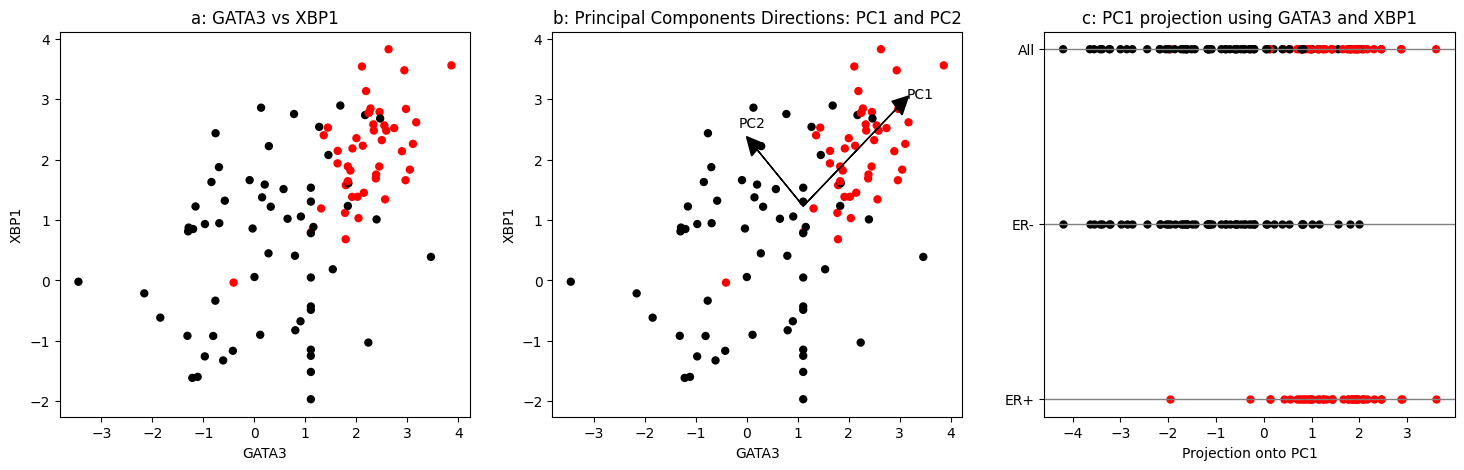

<Figure size 600x300 with 0 Axes>

In [24]:
# 1. Extracting the expression levels of the XBP1 and GATA3 genes in the 105 patients and producing the Figure a

# Extracting gene columns
GATA3 = filtered_data['GATA3']
XBP1 = filtered_data['XBP1']
# print(GATA3,XBP1)

# Plotting: GATA3 (X) vs XBP1 (Y)
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(18, 5))
colors = ['red' if colour_class == 1 else 'black' for colour_class in class_labels['class']]
ax1.scatter(GATA3, XBP1, c=colors, s=25)
ax1.set_xlabel('GATA3')
ax1.set_ylabel('XBP1')
ax1.set_title("a: GATA3 vs XBP1")


# 2. Running PCA on the matrix and projecting the 2-D points on the PC1 component and generating figure c.
# Defining pca function which takes the data as input and gives the projection, first principal component, second principal component and the mean values
def pca(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    centered = data - mean
    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eig(cov)
    
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    pc1 = eigvecs[:, 0] * std * np.sqrt(eigvals[0])
    pc2 = eigvecs[:, 1] * std * np.sqrt(eigvals[1])
    projection = centered @ eigvecs

    return projection, pc1, pc2, mean

# Extracting only the columns with XBP1 and GATA3 expression levels into gene_exprlevel DataFra,e
gene_exprlevel=filtered_data[['GATA3','XBP1']]
projection,pc1,pc2,mean_vec = pca(gene_exprlevel)


# Plotting principal components directions as in figure b
ax2.scatter(GATA3,XBP1,c=colors, s=25)
ax2.set_xlabel("GATA3")
ax2.set_ylabel("XBP1")
ax2.set_title("b: Principal Components Directions: PC1 and PC2")
ax2.arrow(mean_vec.iloc[0], mean_vec.iloc[1], pc1.iloc[0], pc1.iloc[1],head_width=0.3, head_length=0.3, fc='black', ec='black')
ax2.text(mean_vec['GATA3'] + pc1['GATA3']*1.1, mean_vec['XBP1'] + pc1['XBP1']*1.1, 'PC1', color='black')
ax2.text(mean_vec['GATA3'] + pc2['GATA3']*1.4, mean_vec['XBP1'] + pc2['XBP1']*1.4, 'PC2', color='black')
ax2.arrow(mean_vec.iloc[0], mean_vec.iloc[1], pc2.iloc[0], pc2.iloc[1],head_width=0.3, head_length=0.3, fc='black', ec='black')

# We need only PC1 to generate figure c
pc1 = projection.iloc[:,0]

# print(pc1)

# Plotting the projected data onto PC1 colour coded based upon ER+ or ER- class
plt.figure(figsize=(6, 3))
labels=['All','ER-','ER+']
for i in range(len(labels)): # Loop to plot one-by-one projections based upon classes All,ER+,ER-,
    if labels[i] == 'All':
        v = pc1 # Take all the data points for All
    elif labels[i] == 'ER-':
        v = pc1[class_labels['class'] == 0] # Take only those points with class label 0
    else: # ER+
        v = pc1[class_labels['class'] == 1] # Take only those points with class label 1
    y = np.ones_like(v) * (3- i) # Generating y axis values as equal to make the line horizonta 

    # Colour coding
    color = 'black' if labels[i] == 'ER-' else 'red'
    if i==0:
        color=['black' if colour_code==0 else 'red' for colour_code in class_labels['class']]

    # Plotting
    ax3.axhline((3-i), linestyle='-', color='grey', linewidth=1)
    ax3.scatter(v, y, c=color, s=25)

ax3.set_yticks([3, 2, 1])
ax3.set_yticklabels(labels)
ax3.set_xlabel("Projection onto PC1")
ax3.set_title("c: PC1 projection using GATA3 and XBP1")

plt.tight_layout()
plt.show()

Thus we can see it almost matches the result given in the Nature Primer